In [1]:
!pip install -U googlemaps

  Preparing metadata (setup.py) ... done
  Created wheel for googlemaps: filename=googlemaps-4.10.0-py3-none-any.whl size=40714 sha256=c2488212d1da0cbf3b06db52e90e3c4a29462c5003c1471aa0f9e17b5a6e36bc
  Stored in directory: /root/.cache/pip/wheels/4c/6a/a7/bbc6f5c200032025ee655deb5e163ce8594fa05e67d973aad6
Successfully built googlemaps


In [2]:
import json
import time
import pickle
from datetime import datetime

from google.colab import drive

import numpy as np
import pandas as pd
import requests
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import geopandas as gpd
from shapely.geometry import Point
import folium
from folium.plugins import MarkerCluster

from matplotlib.colors import LinearSegmentedColormap

%config InlineBackend.figure_format = 'png2x'

custom_colors = [
    "#214B63",  # темно-зеленый
    "#4F8166",  # зеленый
    "#97B364",  # светло-зеленый
    "#AF3123",  # красный
    "#244993"   # темно-синий
]

custom_dark_blue_gradient = [
    "#D6E0F0",  # очень светлый
    "#9AB0D1",  # светлый синий
    "#244993",  # базовый цвет
    "#1A3270",  # более тёмный
    "#0F1D3F"   # почти чёрный
]

custom_green_gradient = [
    "#D1E0DA",  # очень светлый
    "#9FBCAF",  # светло-зеленый
    "#4F8166",  # базовый цвет
    "#355946",  # более тёмный
    "#1B2E23"   # почти чёрный
]

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_green", custom_green_gradient
)

In [3]:
drive.mount('/content/drive')

folder_path = '/content/drive/My Drive/_Project/Files'
file_path = '/content/drive/My Drive/_Project/Files/dataframes_Yuniov.pkl'

Mounted at /content/drive


In [4]:
with open(file_path, 'rb') as f:
    new_data = pickle.load(f)

calls = new_data['calls']
contacts = new_data['contacts']
spend = new_data['spend']
deals = new_data['deals']

#`Анализ временных рядов`

##1. Проанализируйте тенденцию создания сделок с течением времени и их связь с звонками.


In [6]:
deals['Deal Created Date'] = deals['Created Time'].dt.to_period('M')
calls['Call Date'] = calls['Call Start Time'].dt.to_period('M')

deals_per_month = (
    deals.groupby('Deal Created Date')
    .size()
    .reset_index(name='Deals Total'))

calls_per_month = (
    calls.groupby('Call Date')
    .size()
    .reset_index(name='Calls Total'))

monthly_calls_deals = pd.merge(
    calls_per_month.rename(columns={'Call Date': 'Month'}),
    deals_per_month.rename(columns={'Deal Created Date': 'Month'}),
    on='Month',
    how='outer'
).fillna(0)

monthly_calls_deals['Deals % of Calls'] = (
    monthly_calls_deals['Deals Total']
    / monthly_calls_deals['Calls Total'] * 100
).round(2)

In [7]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(
        x=monthly_calls_deals['Month'].dt.to_timestamp(),
        y=monthly_calls_deals['Calls Total'],
        mode='lines+markers',
        name='Calls Total',
        line=dict(width=3, color='#AF3123'),
        marker=dict(size=8, symbol='diamond')
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=monthly_calls_deals['Month'].dt.to_timestamp(),
        y=monthly_calls_deals['Deals Total'],
        mode='lines+markers',
        name='Deals Total',
        line=dict(width=3, color='#244993'),
        marker=dict(size=8, symbol='circle')
    ),
    secondary_y=True,
)

fig.update_layout(
    title='Trends of Deals and Calls by Month',
    title_font=dict(size=18),
    hovermode="x unified",
    plot_bgcolor="white",
    template='plotly_white',
    xaxis=dict(
        dtick="M1",
        tickformat="%Y-%m",
        title="Date",
        tickangle=-45,
        title_font=dict(size=14),
        showline=True,
        linecolor="black",
        linewidth=1
    ),
    yaxis=dict(
        title="Calls Total",
        title_font=dict(size=14),
        showline=True,
        linecolor="black",
        linewidth=1
    ),
    yaxis2=dict(
        title="Deals Total",
        title_font=dict(size=14),
        showline=True,
        linecolor="black",
        linewidth=1,
        showgrid=False
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=0.95
    )
)

fig.show()

Выводы:
- С июня 2023 до апреля 2024 количество звонков и количество сделок постепенно растёт. Это указывает на рост активности бизнеса и расширение клиентской базы, рекламные акции.
- Тренды у двух показателей схожи: рост звонков сопровождается ростом сделок.
- Можно предположить, что звонки напрямую влияют на конверсию в сделки.
- Апрель 2024 — переломный момент. Наблюдаем наибольшую активность: звонки достигают более 12,7тыс., сделки — почти 3100. После этого наблюдается резкое падение обоих показателей.
- В мае–июне 2024 количество звонков снижается примерно на 30–40%, а количество сделок — почти вдвое. Это может быть связано с сезонностью (например, конец квартала или финансового года, летние каникулы) или внутренними изменениями (сокращение ресурсов, смена стратегии).

## 2. Изучите распределение времени закрытия сделок и продолжительность периода от создания до закрытия.

Принимаю решение отфильтровать даты закрытия (cutoff_month), так как после 2024-09 в базе имеются только 2 значения и они сильно искажают графическое представление

In [8]:
deals['Deals Closing Month'] = deals['Closing Date'].dt.to_period('M')

cutoff_month = pd.Period('2024-09', freq='M')

deals_closing_per_month_all = (
    deals[deals['Deals Closing Month'] < cutoff_month]
    .groupby('Deals Closing Month')
    .size()
    .reset_index(name='Deals Closing Count')
)

deals_closing_per_month_success = (
    deals[deals['Stage'] == 'Payment Done']
    .groupby('Deals Closing Month')
    .size()
    .reset_index(name='Deals Successful')
)

deals['Duration'] = (
    deals['Closing Date'] - deals['Created Time']).dt.days.abs()

duration_stats_per_month = (
    deals[deals['Deals Closing Month'] < cutoff_month]
    .groupby('Deals Closing Month')['Duration']
    .agg(['mean', 'median'])
    .rename(columns={
        'mean': 'Average Duration Month',
        'median': 'Median Duration Month'
    })
    .round(1)
    .reset_index()
)

In [9]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(
        x=deals_closing_per_month_all['Deals Closing Month'].dt.to_timestamp(),
        y=deals_closing_per_month_all['Deals Closing Count'],
        mode='lines+markers',
        name='All Deals Closed',
        line=dict(width=3, color='#97B364'),
        marker=dict(size=8, symbol='circle')
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=deals_closing_per_month_success[
            'Deals Closing Month'].dt.to_timestamp(),
        y=deals_closing_per_month_success['Deals Successful'],
        mode='lines+markers',
        name='Successful Deals',
        line=dict(width=3, color='#244993'),
        marker=dict(size=8, symbol='square')
    ),
    secondary_y=True
)

fig.update_layout(
    title='Trends of Deals Closing by Month',
    title_font=dict(size=18),
    hovermode="x unified",
    plot_bgcolor="white",
    template='plotly_white',
    xaxis=dict(
        dtick="M1",
        tickformat="%Y-%m",
        title="Date",
        tickangle=-45,
        title_font=dict(size=14),
        showline=True,
        linecolor="black",
        linewidth=1
    ),
    yaxis=dict(
        title="All Deals Count",
        title_font=dict(size=14),
        showline=True,
        linecolor="black",
        linewidth=1
    ),
    yaxis2=dict(
        title="Successful Deals Count",
        title_font=dict(size=14),
        showline=True,
        linecolor="black",
        linewidth=1,
        showgrid=False
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=0.95
    )
)

fig.show()

Выводы:
- Обе метрики (все закрытые сделки и успешные сделки) постепенно растут на протяжении большей части анализируемого периода, особенно заметно этот рост проявился с осени 2023 года по апрель 2024 года.
- Похожие колебания графиков указывают на то, что динамика общего количества закрытых сделок и успешных сделок тесно связана между собой. Возможно, это обусловлено сезонностью или внешними факторами (например, маркетинговыми кампаниями).
- В декабре 2023 года наблюдается небольшой спад, что характерно для конца года.
- Резкий рост с начала 2024 года и столь же выраженное падение после апреля могут свидетельствовать о влиянии краткосрочных факторов (запуск новой акции, изменения в продукте или услуге)

Провожу анализ статусов сделок и их доли в общем количестве

In [10]:
stage_counts = deals['Stage'].value_counts().reset_index()
stage_counts.columns = ['Stage', 'Deals Total']

total_deals = stage_counts['Deals Total'].sum()

stage_counts['Deals % of Total'] = (
    stage_counts['Deals Total'] / total_deals * 100).round(2)

In [11]:
fig = go.Figure(
    go.Bar(
        x=stage_counts['Stage'],
        y=stage_counts['Deals Total'],
        text=stage_counts['Deals % of Total'].astype(str) + '%',
        textposition='auto',
        marker_color='#244993',
        hovertemplate=(
            'Stage: %{x}<br>' +
            'Deals Total: %{y}<br>' +
            'Deals % of Total: %{text}<extra></extra>'
        )
    )
)

fig.update_layout(
    title='Deals by Stage',
    xaxis_title='Stage',
    yaxis_title='Deals Total',
    plot_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    title_font=dict(size=18)
)

fig.show()

Основная часть сделок сосредоточена на пяти ключевых стадиях. Дальнейший анализ будет проводиться по ним.

Сравниваю средние и медианные значения по месяцам, чтобы оценить влияние выбросов и определить, какое значение более репрезентативно для анализа.

In [12]:
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=duration_stats_per_month['Deals Closing Month'].dt.to_timestamp(),
        y=duration_stats_per_month['Average Duration Month'],
        name='Average Duration',
        marker_color='#4F8166',
        text=duration_stats_per_month['Average Duration Month'],
        textposition='outside',
        hoverinfo='skip'
    )
)

fig.add_trace(
    go.Scatter(
        x=duration_stats_per_month['Deals Closing Month'].dt.to_timestamp(),
        y=duration_stats_per_month['Median Duration Month'],
        mode='lines+markers+text',
        name='Median Duration',
        line=dict(color='orange', width=3, dash='dash'),
        marker=dict(size=6),
        text=duration_stats_per_month['Median Duration Month'],
        textposition='top center',
        textfont=dict(color='white'),
        hoverinfo='skip'
    )
)

fig.update_layout(
    title='Average and Median Duration of Deals by Month',
    xaxis=dict(
        title='Deals Closing Month',
        tickformat='%Y-%m',
        tickangle=-45,
        dtick='M1',
        showgrid=False,
        showline=True,
        linecolor="black",
        linewidth=1
    ),
    yaxis=dict(
        title='Duration (days)',
        showgrid=False,
        gridcolor='lightgray',
        showticklabels=False,
        showline=True,
        linecolor="black",
        linewidth=1
    ),
    plot_bgcolor='white',
    hovermode=False,
    title_font=dict(size=18),
    bargap=0.05,
    legend=dict(
        x=0,
        y=1,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.7)",
        borderwidth=0
    )
)

fig.show()

Выводы:
- Средняя продолжительность сделок значительно выше медианной во все месяцы, что указывает на наличие длинных сделок, влияющих на среднее, и асимметричное распределение по длительности.
- Значительное расхождение средней и медианной продолжительности говорит о том, что для анализа лучше ориентироваться на медиану, так как она меньше подвержена влиянию редких длинных сделок.
- С учетом полученных данных можно предполагать, что большая часть созданных сделок закрывается в течение месяца.

Далее принято решение разделить сделки на группы по длительности закрытия: 0–1 день (быстрые, сюда, как правило, попадают Lost), 1 неделя, 2 недели, 3 недели, 4 недели, 5 недель и более 5 недель. Такое деление обусловлено расчетом средней длительности закрытия и является промежутком времени в организациях, когда можно подводить итоги.

In [13]:
filter_stages = [
    'Call Delayed',
    'Lost',
    'Payment Done',
    'Waiting For Payment',
    'Registered on Webinar'
]

filter_deals = deals[deals['Stage'].isin(filter_stages)].copy()

filter_deals['Duration_Group'] = filter_deals['Duration'].apply(
    lambda x: 'Instant (0-1 day)' if pd.notna(x) and x <= 1 else None
)

filter_deals.loc[filter_deals['Duration'] > 1, 'Duration_Group'] = (
    ((filter_deals['Duration'] - 1) // 7 + 1)
    .clip(upper=5)
    .astype('Int64')
    .astype(str) + ' week'
)

filter_deals.loc[
    (filter_deals['Duration'] > 1)
    & (((filter_deals['Duration'] - 1) // 7 + 1) > 5),
    'Duration_Group'
] = 'More than 5 weeks'

duration_groups = (
    filter_deals.groupby(['Stage', 'Duration_Group'])
    .size()
    .reset_index(name='Deals Closing Count Stage')
)

duration_groups['Deals Closing % Stage'] = (
    duration_groups.groupby('Stage')['Deals Closing Count Stage']
    .transform(lambda x: (x / x.sum() * 100).round(2))
)

display(duration_groups)

,Stage,Duration_Group,Deals Closing Count Stage,Deals Closing % Stage
0,Call Delayed,1 week,45,20.09
1,Call Delayed,2 week,16,7.14
2,Call Delayed,3 week,6,2.68
3,Call Delayed,4 week,7,3.12
4,Call Delayed,5 week,4,1.79
5,Call Delayed,Instant (0-1 day),95,42.41
6,Call Delayed,More than 5 weeks,51,22.77
7,Lost,1 week,3683,26.73
8,Lost,2 week,1303,9.46
9,Lost,3 week,547,3.97


In [16]:
duration_order = [
    'Instant (0-1 day)',
    '1 week',
    '2 week',
    '3 week',
    '4 week',
    '5 week',
    'More than 5 weeks'
]

duration_groups['text_inside'] = (
    duration_groups['Deals Closing Count Stage'].astype(str) +
    ' deals closing | ' +
    duration_groups['Deals Closing % Stage'].astype(str) + '%'
)

fig = px.bar(
    duration_groups,
    x='Deals Closing % Stage',
    y='Stage',
    color='Duration_Group',
    category_orders={'Duration_Group': duration_order},
    color_discrete_sequence=custom_colors,
    orientation='h',
    text='text_inside',
    title='Clousing Deals by Stage',
    hover_data={
        'text_inside': False
    }
)

fig.update_traces(
    textposition='inside',
    hoverinfo='skip'
)

fig.update_layout(
    xaxis_title='Percent within Stage',
    yaxis_title='Stage',
    plot_bgcolor='white',
    bargap=0.15,
    title_font=dict(size=18),
    legend_title='Duration Groups',
)

fig.show()

Выводы:
1. Стадия "Lost"
- Основная доля потерянных сделок происходит очень быстро: 44% клиентов теряются в первый день взаимодействия, ещё 27% — в течение первой недели.
- Для образовательной компании это отражает особенности воронки продаж: большинство клиентов после первого контакта фильтруются и не совершают покупку.
2. Стадии "Call Delayed", "Registered on Webinar", "Waiting for Payment"
- Проблема с заполнением статусов закрытия.
- Из 2 175 сделок в "Call Delayed", 2 068 в "Registered on Webinar" и 324 в "Waiting for Payment" на графике показаны единицы с датой закрытия — менее 1% от общего числа.
- Это говорит о том, что на этих промежуточных стадиях: либо отсутствует процедура контроля и завершения сделок; либо не реализована автоматизация снятия "зависших" с учета, и такие сделки остаются в системе не закрытыми. Рекомендация: доработать алгоритмы и бизнес-процессы фиксации исхода сделок. Возможно, именно здесь теряется большое количество клиентов без аналитического учёта причин.
3. Стадия "Payment Done"
- Распределение сделок равномерное: сделки закрываются с разной длительностью — есть быстрые, средние и длинные сценарии.
- Это закономерно объясняется особенностями отсроченных или частичных оплат (например, рассрочка за обучающие курсы), что приводит к равномерному распределению дат завершения.
4. Для повышения качества сквозной аналитики и реального контроля воронки важно внедрить регламент автоматического или ручного завершения сделок на этих этапах.



#`Анализ эффективности кампаний`

## 1. Сравните эффективность различных кампаний с точки зрения генерации лидов и коэффициента конверсии.

In [17]:
deals_campaign_analysis = deals.groupby('Campaign').agg(
    Deals_Total=('Stage', 'count'),
    Deals_Successful=('Stage', lambda x: (x == 'Payment Done').sum()),
    Conversion_Rate=(
    'Stage',
    lambda x: (x == 'Payment Done').sum() / len(x) * 100 if len(x) > 0 else 0
    ),
    Total_Sales=('Initial Amount Paid', 'sum'),
    Avg_Time_to_Close_Campaign=('Duration', 'mean'),
    Median_Time_to_Close_Campaign=('Duration', 'median')
).reset_index()

deals_campaign_analysis['Avg_Time_to_Close_Campaign'] = (
    deals_campaign_analysis['Avg_Time_to_Close_Campaign'].round(1))

deals_campaign_analysis['Median_Time_to_Close_Campaign'] = (
    deals_campaign_analysis['Median_Time_to_Close_Campaign'].round(1))

deals_campaign_analysis['Conversion_Rate'] = (
    deals_campaign_analysis['Conversion_Rate'].round(2))

Оцениваю лучшие 10 campaigns по общему количеству сделок, так как по ним достаточно данных и можно увидеть динамику и закономерности

In [18]:
top_10_campaigns = deals_campaign_analysis.sort_values(
    by='Deals_Total', ascending=False
).head(10)

top_10_campaigns

,Campaign,Deals_Total,Deals_Successful,Conversion_Rate,Total_Sales,Avg_Time_to_Close_Campaign,Median_Time_to_Close_Campaign
117,performancemax_digitalmarkt_ru_DE,2650,112,4.23,410100.0,12.8,1.0
151,youtube_shorts_DE,1635,53,3.24,244300.0,13.1,2.0
17,12.07.2023wide_DE,1575,48,3.05,266000.0,13.8,3.0
1,02.07.23wide_DE,975,52,5.33,195950.0,18.4,5.0
4,04.07.23recentlymoved_DE,750,31,4.13,132800.0,16.6,4.0
3,03.07.23women,612,31,5.07,119450.0,20.6,4.0
59,Dis_DE,581,30,5.16,117450.0,17.4,3.0
7,07.07.23LAL_DE,542,28,5.17,126300.0,19.1,3.0
18,12.09.23interests_Uxui_DE,531,27,5.08,136450.0,19.5,5.0
39,24.09.23retargeting_DE,479,17,3.55,116050.0,19.4,3.0


Выводы:
Значительное расхождение средней и медианной продолжительности говорит о том, что для анализа лучше ориентироваться на медиану, так как она меньше подвержена влиянию редких длинных сделок.

In [19]:
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=top_10_campaigns['Campaign'],
        y=top_10_campaigns['Deals_Total'],
        name='Total Deals (Leads)',
        text=top_10_campaigns['Deals_Total'],
        textposition='outside',
        hovertemplate=(
            'Conversion_Rate: %{customdata[1]}%<br>' +
            'Median_Time_to_Close_Campaign: %{customdata[2]} days<br>'
            '<extra></extra>'
        ),
        customdata=top_10_campaigns[[
            'Deals_Successful',
            'Conversion_Rate',
            'Median_Time_to_Close_Campaign'
        ]].values,
        marker=dict(
            color=top_10_campaigns['Conversion_Rate'],
            colorscale=custom_green_gradient,
            showscale=True,
            colorbar=dict(title="Conversion Rate (%)")
        )
    )
)

fig.add_trace(
    go.Bar(
        x=top_10_campaigns['Campaign'],
        y=top_10_campaigns['Total_Sales'],
        name='Total Sales',
        text=top_10_campaigns['Total_Sales'],
        textposition='outside',
        hovertemplate=(
            'Conversion_Rate: %{customdata[1]}%<br>' +
            'Median_Time_to_Close_Campaign: %{customdata[2]} days<br>'
            '<extra></extra>'
        ),
        customdata = top_10_campaigns[[
            'Deals_Successful',
            'Conversion_Rate',
            'Median_Time_to_Close_Campaign'
        ]].values,
        marker=dict(
            color=top_10_campaigns['Conversion_Rate'],
            colorscale=custom_green_gradient,
            showscale=False
        )
    )
)

fig.data[1].visible = False

fig.update_layout(
    updatemenus=[dict(
        type="buttons",
        x=-0.07,
        y=1,
        showactive=True,
        buttons=[
            dict(label="Show Leads",
                 method="update",
                 args=[{"visible": [True, False]},
                       {"yaxis": {"title": "Total Deals (Leads)",
                                  "range": [0,
                                            top_10_campaigns[
                                                'Deals_Total'].max() * 1.2],
                                                "showticklabels": False}}]),
            dict(label="Show Sales",
                 method="update",
                 args=[{"visible": [False, True]},
                       {"yaxis": {"title": "Total Sales (€)",
                                  "range": [0,
                                            top_10_campaigns[
                                                'Total_Sales'].max() * 1.2],
                                                "showticklabels": False}}])
        ]
    )],
    title='Top 10 Campaign Performance',
    title_font=dict(size=18),
    xaxis=dict(title='Campaign',
               tickangle=-45
    ),
    yaxis=dict(
        title='Total Deals (Leads)',
        showticklabels=False
    ),
    plot_bgcolor='white',
    hovermode='x unified'
)

fig.show()

Выводы:
- performance_max_digitalmarkt_ru_DE - лидирующая Campaign по объёму. Эта Campaign самая продуктивная и  привела к наибольшему числу лидов (2650).
- youtube_shorts_DE и 12.07.23wide_DE занимают второе и третье места (1635 и 1575 соответственно), что также говорит о высокой вовлечённости и охвате. При этом, данные Campaign имеют плохую конверсию, что говорит о проблемах скорее продавцов либо неправильном понимании показываемой рекламы потенциальными клиентами.
- Также стоит отметить ряд Campaign (показаны темно-зеленым цветом), имеющих большую конверсию при достаточно большом охвате. Возможно, эти Campaign имеют узкую направленность на аудиторию.
- Мы видим классическую длинную воронку: несколько Campaign дают основной приток трафика, остальные работают на охват или специальные сегменты.
- Для дальнейшего роста важно не только масштабировать топовые Campaign, но и оптимизировать конверсию в менее массовых — они иногда показывают наибольшую отдачу на одного лида.
- Следить за динамикой конверсии: если у лидера (performance_max) эффективность ниже, стоит проверить настройки, потому что большой трафик при низкой конверсии увеличивает стоимость привлечения клиента.
- При анализе Sales (продаж) действительно видна динамика Campaign по  эффективности. Динамический рост выручки или стабильный поток платежей показывает, что проводимые маркетинговые усилия работают и приносят доход компании. Визуально видна взаимосвязь количества привлеченных потенциальных клиентов и продаж.



In [20]:
spend_campaign_analysis = spend.groupby('Campaign').agg(
    Total_Impressions=('Impressions', 'sum'),
    Total_Spend=('Spend', 'sum'),
    Total_Clicks=('Clicks', 'sum')
).reset_index()

top_10_spend = spend_campaign_analysis.sort_values(
    by='Total_Spend', ascending=False
).head(10)

top_10_spend['Total_Spend'] = top_10_spend['Total_Spend'].round(0)

top_10_clicks = spend_campaign_analysis.sort_values(
    by='Total_Clicks', ascending=False
).head(10)

In [21]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Top 10 Campaigns by Spend', 'Top 10 Campaigns by Clicks'),
    column_widths=[0.5, 0.5],
    horizontal_spacing=0.15
)

fig.add_trace(
    go.Bar(
        x=top_10_spend['Total_Spend'],
        y=top_10_spend['Campaign'],
        orientation='h',
        marker_color='#4F8166',
        name='Spend',
        hovertemplate='Spend: €%{x}<extra></extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=top_10_clicks['Total_Clicks'],
        y=top_10_clicks['Campaign'],
        orientation='h',
        marker_color='#244993',
        name='Clicks',
        hovertemplate='Clicks: %{x}<extra></extra>'
    ),
    row=1, col=2
)

fig.update_layout(
    showlegend=False,
    title_text='Comparison of Top 10 Campaigns by Spend and Clicks',
    plot_bgcolor='white'
)

fig.update_yaxes(autorange='reversed', row=1, col=1)
fig.update_yaxes(autorange='reversed', row=1, col=2)

fig.update_xaxes(title_text='Total Spend (€)', row=1, col=1)
fig.update_xaxes(title_text='Total Clicks', row=1, col=2)

fig.show()

Выводы:
- Кампания performancemax_eng_DE лидирует и по расходам, и по количеству кликов. Это означает, что кампания максимально активно инвестировала средства и получила пропорционально высокий отклик.
- Остальные кампании расходуют меньше бюджета, но при этом не все получают высокие клики. Например, 12.07.23wide_De и discovery_DE имея одинаковый бюджет, получают разницу в кликах в 2 раза. Необходимо проанализировать, чем это вызвано.
- 03.07.23women и 07.07.23LAL_DE имеют относительно небольшие расходы и показывают небольшое количество кликов, что может говорить о низкой отдаче на единицу затрат.
- На визуализации с кликами отображены 2 кампании (discovery_wide_De и 1performancemax_wide_PL), которые имеют неплохую кликабельность с учетом того, что они не попали в топ 10 кампаний по затратам. С другой стороны,  на визуализации с затратами мы видим 2 кампании (07.07.23LAL_DE и 12.09.23interests_Uxui_de), на которые мы потратили деньги, но в топ 10 кликабельности они не вошли. Значит, данные кампании прошли без выгодности для школы.
- Кампании с низким количеством кликов при больших расходах могут быть кандидатами для оптимизации бюджета.
- Кампании с хорошим соотношением кликов к расходам могут быть масштабированы для увеличения охвата при том же бюджете.

## 2. Оцените эффективность различных маркетинговых источников (Source) в генерировании качественных лидов.

In [22]:
deals_source_analysis = deals.groupby('Source').agg(
    Deals_Total=('Stage', 'count'),
    Deals_Successful=('Stage', lambda x: (x == 'Payment Done').sum()),
    Conversion_Rate=('Stage', lambda x: round(
        (x == 'Payment Done').sum() / len(x) * 100 if len(x) > 0 else 0, 2))
).reset_index()

# убрал Offline - там 2 лица, без денег и успеха
deals_source_analysis = (
    deals_source_analysis[deals_source_analysis['Source'] != 'Offline'])

spend_source_analysis = spend.groupby('Source').agg(
    Spend_Total=('Spend', 'sum')
).reset_index()

source_analysis = deals_source_analysis.merge(
    spend_source_analysis,
    on='Source',
    how='left'
)

source_analysis

,Source,Deals_Total,Deals_Successful,Conversion_Rate,Spend_Total
0,Bloggers,1089,39,3.58,13439.00
1,CRM,1655,24,1.45,0.00
2,Facebook Ads,4849,202,4.17,33754.72
3,Google Ads,4223,173,4.10,57798.60
4,Organic,2586,146,5.65,0.00
5,Partnership,201,4,1.99,0.00
6,SMM,1730,91,5.26,7269.52
7,Telegram posts,1001,40,4.00,6860.36
8,Tiktok Ads,2051,56,2.73,11985.67
9,Webinar,376,26,6.91,2874.04


In [23]:
fig = px.scatter(
    source_analysis,
    x='Spend_Total',
    y='Conversion_Rate',
    size='Deals_Total',
    color='Conversion_Rate',
    hover_name='Source',
    hover_data={
        'Deals_Successful': True,
        'Deals_Total': True,
        'Spend_Total': True,
        'Conversion_Rate': True,
        'Source': False
    },
    text='Source',
    title='Conversion Rate vs Spend by Source',
    labels={
        'Spend_Total': 'Total Spend (€)',
        'Conversion_Rate': 'Conversion Rate (%)',
        'Deals_Total': 'Total Deals',
        'Deals_Successful': 'Successful Deals'
    },
    color_continuous_scale='Viridis',
    size_max=40
)

fig.update_traces(
    textposition='top center',
    textfont=dict(size=10, color='black')
)

fig.update_layout(
    xaxis_title='Total Spend (€)',
    yaxis_title='Conversion Rate (%)',
    plot_bgcolor='white',
    template='plotly_white',
    xaxis=dict(
        visible=True,
        showline=True,
        linecolor='black'
    ),
    yaxis=dict(
        visible=True,
        showline=True,
        linecolor='black'
    )
)

fig.show()

Выводы:
- Facebook Ads и Google Ads - источники привлекают наибольшее количество лидов, что подтверждается крупным размером пузырей. Однако их конверсия ниже, чем у ряда других каналов. Необходимо провести аудит Facebook Ads и Google Ads, чтобы повысить их конверсию. Возможно, стоит пересмотреть таргетинг.
- Organic и SMM демонстрируют высокую конверсию при хорошем охвате. Это делает органический и SMM трафик одними из наиболее качественных и перспективных источников. Целесообразно рассматривать этот ресурс для развития. При этом, затрат на рекламу мы либо не делаем, либо они незначительны.
- Webinar показывает высокую конверсию. Необхомидо увеличивать привличение потенциальных клиентов, но это повлечет увелечение затрат на рекламу.
- Bloggers, YouTube, TikTok имеют показатели конверсии ниже средних. По затратам на рекламу образуют условную группу. Могут быть использованы как дополнительные каналы, но требуют оптимизации. Над конверсией точно стоит поработать дополнительно.

#`Анализ эффективности работы отдела продаж`

## 1. Оцените эффективность отдельных владельцев сделок и рекламных кампаний с точки зрения количества обработанных сделок, коэффициента конверсии и общей суммы продаж.

In [24]:
deals_owner_analysis = deals.groupby('Deal Owner Name').agg(
    Deals_Total=('Stage', 'count'),
    Deals_Successful=('Stage', lambda x: (x == 'Payment Done').sum()),
    Deals_Closed_All=('Closing Date', lambda x: x.notna().sum()),
    Conversion_Rate=(
    'Stage',
    lambda x: (x == 'Payment Done').sum() / len(x) * 100 if len(x) > 0 else 0
    ),
    Total_Sales=(
        'Initial Amount Paid',
        lambda x: np.where(deals.loc[
            x.index, 'Stage'] == 'Payment Done', x, 0).sum()),
    Avg_Time_to_Close=('Duration', 'mean'),
    Median_Time_to_Close=('Duration', 'median')
).reset_index()

deals_owner_analysis[
    ['Avg_Time_to_Close', 'Median_Time_to_Close', 'Conversion_Rate']] = \
    deals_owner_analysis[
        ['Avg_Time_to_Close', 'Median_Time_to_Close', 'Conversion_Rate']
].round(1)

total_deals_all = deals_owner_analysis['Deals_Total'].sum()

# deals_owner_analysis

Для расчета времени работы специалиста в компании делаю фильтрацию даты до 2024-07, так как за этой датой есть 2 значения сделок и они искажают информацию

In [25]:
deals['Closing Date'] = pd.to_datetime(deals['Closing Date'])

june_2024_deals = deals[
    (deals['Closing Date'].dt.year == 2024) &
    (deals['Closing Date'].dt.month == 6)
]

last_closing_date = june_2024_deals['Closing Date'].max()

first_deals = deals.groupby('Deal Owner Name').agg(
    First_Deal=('Created Time', 'min')
).reset_index()

first_deals['Months_Working_Global'] = (
    (last_closing_date - first_deals['First_Deal']).dt.days / 30.44
).round(1)

deals_owner_analysis = deals_owner_analysis.merge(
    first_deals[['Deal Owner Name', 'Months_Working_Global']],
    on='Deal Owner Name',
    how='left'
)

deals_owner_analysis

,Deal Owner Name,Deals_Total,Deals_Successful,Deals_Closed_All,Conversion_Rate,Total_Sales,Avg_Time_to_Close,Median_Time_to_Close,Months_Working_Global
0,Alice Johnson,25,0,25,0.0,0.0,1.2,1.0,11.4
1,Amy Green,66,0,30,0.0,0.0,2.0,1.0,4.7
2,Ben Hall,1329,46,569,3.5,57700.0,4.7,1.0,10.5
3,Bob Brown,334,0,322,0.0,0.0,1.9,1.0,11.7
4,Cara Iverson,1025,27,680,2.6,149900.0,8.0,3.0,10.1
5,Charlie Davis,2952,148,2164,5.0,140750.0,19.1,4.0,11.5
6,Diana Evans,1009,1,875,0.1,350.0,8.0,3.0,11.7
7,Eva Kent,452,18,216,4.0,20000.0,4.5,1.0,3.3
8,George King,94,2,26,2.1,900.0,61.2,30.0,11.7
9,Ian Miller,496,8,452,1.6,7550.0,17.6,2.5,11.7


In [26]:
top_10_owners_deals = deals_owner_analysis.sort_values(
    by='Deals_Total', ascending=False
).head(10).reset_index(drop=True)

top_10_owners_deals = top_10_owners_deals.sort_values(
    'Deals_Total',
    ascending=True
)

top_10_owners_deals['text_inside'] = (
    top_10_owners_deals['Deals_Successful'].astype(str) + ' of ' +
    top_10_owners_deals['Deals_Total'].astype(str) + ' deals successful\n' +
    '/ CR: ' + top_10_owners_deals['Conversion_Rate'].astype(str) + '%'
)

fig = px.bar(
    top_10_owners_deals,
    x='Deals_Total',
    y='Deal Owner Name',
    orientation='h',
    color='Conversion_Rate',
    text='text_inside',
    color_continuous_scale=custom_dark_blue_gradient,
    title='Top 10 Deal Owners by Total Deals',
    hover_data={
        'Deals_Total': False,
        'Conversion_Rate': False,
        'Median_Time_to_Close': True,
        'Total_Sales': True,
        'Months_Working_Global': True,
        'Deal Owner Name': False,
        'text_inside': False
    }
)

fig.update_traces(textposition='inside', insidetextanchor='middle')

fig.update_layout(
    xaxis_title='Total Deals',
    yaxis_title='Deal Owner Name',
    plot_bgcolor='white',
    title_font=dict(size=18),
    coloraxis_colorbar=dict(title='Conversion Rate (%)')
)

fig.show()

Выводы:
- Продолжительность работы специалистов в компании от 5 до 12 месяцев (данные всего анализируемого датасета).
- Лидером по количеству сделок является Charlie Davis (2952 сделки), что значительно выше других. Другие сотрудники, такие как Julia Nelson и Ulysses Adams, также имеют высокий объем сделок (более 2000). В сравнении с другоми специалистами этой выборки, у них хорошая конверсия, что явно выделяет их как отличных работников.
- У Diana Evans объем сделок - 1009. При этом очень низкая конверсия 0.1% (1 успешная сделка). Данный спеалист демонстрирует очень плохие показатели.  
- Необходимо соблюдать баланс между количеством сделок и успешностью.
- Перераспределение части сделок от перегруженных специалистов к менее загруженным может повысить общую эффективность.
- Необходимо провести обучение или анализ процессов у сотрудников с низкой конверсией для улучшения показателей.
- Отдельное внимание к Ulysses Adams — его методы работы можно использовать как успешный кейс.

In [27]:
top_10_owners_conversion = deals_owner_analysis.sort_values(
    by='Conversion_Rate', ascending=False
).head(10).reset_index(drop=True)

top_10_owners_conversion = top_10_owners_conversion.sort_values(
    'Conversion_Rate', ascending=True)

top_10_owners_conversion['text_inside'] = (
    top_10_owners_conversion['Deals_Successful'].astype(str) + ' of '
    + top_10_owners_conversion['Deals_Total'].astype(str) + ' successful\n'
    + '/ Avg Close Deals: '
    + top_10_owners_conversion['Avg_Time_to_Close'].astype(str) + ' days')

fig = px.bar(
    top_10_owners_conversion,
    x='Conversion_Rate',
    y='Deal Owner Name',
    orientation='h',
    color='Deals_Total',
    text='text_inside',
    color_continuous_scale=custom_dark_blue_gradient,
    title='Top 10 Deal Owners by Conversion Rate',
    hover_data={
        'Deals_Total': False,
        'Conversion_Rate': True,
        'Months_Working_Global': True,
        'Deal Owner Name': False,
        'text_inside': False
    }
)

fig.update_traces(textposition='inside', insidetextanchor='middle')

fig.update_layout(
    xaxis_title='Conversion Rate (%)',
    yaxis_title='Deal Owner Name',
    plot_bgcolor='white',
    title_font=dict(size=18),
    coloraxis_colorbar=dict(title='Total Deals')
)

fig.show()

Выводы:
- Наивысшую конверсию демонстрирует Oliver Taylor. Он успешно закрывает почти 31% сделок, что свидетельствует о тщательной и аккуратной работе с каждым клиентом. При этом общий объём его сделок невелик (всего 163), что может говорить о меньшей нагрузке или узкой специализации. Стоит отметить, что среднее время закрытия сделки у данного специалиста состовляет 72 дня. Длительная проработка клиентов дает свой результат в виде конверсии, но одновременно влияет на общий объем обрабатываемых сделок.
- Charlie Davis, Julia Nelson и Ulysses Adams работают с огромным количеством сделок (более 2000–2900) и, возможно, вследствие этого имеют более низкую конверсию. Это типичная ситуация: при высокой нагрузке сложнее поддерживать высокий процент успешных сделок.
- Paula Underwood демонстрируют хороший баланс: значительный объём сделок при достойной конверсии. Такой подход является оптимальным: работа эффективная, а общий вклад в продажи высок.
- Возможно, стоит пересмотреть подход к работе с клиентами или перераспределить часть нагрузки между сотрудниками.
- Для поддержания объёма продаж важно сочетать сотрудников с высокой конверсией и тех, кто обрабатывает большое количество сделок.

In [28]:
df_successful = deals_owner_analysis[
    deals_owner_analysis['Deals_Successful'] > 0].copy()

df_successful['Total_Sales'] = df_successful['Total_Sales'].fillna(0)

fig = px.scatter(
    df_successful,
    x='Deals_Total',
    y='Total_Sales',
    size='Deals_Total',
    color='Deals_Successful',
    hover_name='Deal Owner Name',
    hover_data={
        'Deals_Total': True,
        'Deals_Successful': True,
        'Conversion_Rate': True,
        'Deal Owner Name': False
    },
    text='Deal Owner Name',
    color_continuous_scale='Viridis',
    size_max=40,
    title='Sales per Employee: Total Deals and Sales'
)

fig.update_traces(
    textposition='top center',
    textfont=dict(size=10, color='black')
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_font=dict(size=18),
    template='plotly_white',
    xaxis=dict(
        title='Deals Total',
        zeroline=False,
        showline=True,
        linecolor='gray',
        tickangle=-45,
        showticklabels=True
    ),
    yaxis=dict(
        title='Total Sales',
        zeroline=False,
        showline=True,
        linecolor='gray'
    ),
    coloraxis_colorbar=dict(title='Deals_Successful')
)

fig.show()

Выводы:
- Несколько сотрудников (Sara Iverson, Charlie Davis, Ulysses Adams, Julia Nelson) генерируют наибольшую выручку. Интересный момент: у Sara Iverson количество сделок почти в два раза меньше, чем у коллег, но итоговая выручка выше. Это говорит о высоком качестве её сделок. Таких сотрудников можно считать образцовыми, но важно следить за их нагрузкой, чтобы избежать выгорания.
- У Charlie Davis количество сделок значительно выше (что отражается насыщенным жёлтым цветом на графике), но средняя выручка ниже. Это может свидетельствовать о большем числе регулярных платежей, скидочных предложений или даже о проблемах с задолженностями клиентов.
- Большая часть сотрудников (до 1500 Total Deals) демонстрирует средние показатели. С учетом меньшей загруженности, показатель конверсии у них ниже средней и стоит данных сотрудников дополнительно обучить для возможности перераспределения нагрузки.
- На основании этих данных можно разрабатывать систему мотивации и поощрений, внедрять менторство и дополнительное обучение. Стоит искать резервы роста: у кого много активности, но слабая конверсия в выручку, и наоборот — у кого мало действий, но высокая отдача.



In [29]:
owners_no_success = deals_owner_analysis[
    deals_owner_analysis['Deals_Successful'] == 0
].copy()

top_owners_no_success = owners_no_success.sort_values(
    by='Deals_Total', ascending=False
).head(10).reset_index(drop=True)

top_owners_no_success['text_inside'] = (
    top_owners_no_success['Deals_Closed_All'].astype(str)
    + ' of '
    + top_owners_no_success['Deals_Total'].astype(str)
    + ' deals closed\n'
    + '/ Months Working: '
    + top_owners_no_success['Months_Working_Global'].astype(str)
    + ' months'
)

fig = px.bar(
    top_owners_no_success,
    x='Deals_Total',
    y='Deal Owner Name',
    orientation='h',
    color_discrete_sequence=['#9AB0D1'],
    text='text_inside',
    color_continuous_scale=custom_dark_blue_gradient,
    title='Deal Owners with No Successful Deals by Total Deals',
    hover_data = {
        'Deals_Successful': True,
        'text_inside': False,
        'Deal Owner Name': False
    }
)

min_bar_width = 90

top_owners_no_success['text_pos'] = top_owners_no_success['Deals_Total'].apply(
    lambda x: 'outside' if x < min_bar_width else 'inside'
)

fig.update_traces(
    textposition=top_owners_no_success['text_pos'],
    textfont=dict(size=11, color='black')
)

fig.update_layout(
    xaxis_title='Total Deals',
    yaxis_title='Deal Owner Name',
    plot_bgcolor='white',
    title_font=dict(size=18),
    coloraxis_colorbar=dict(title='Total Deals'),
    coloraxis_showscale=False
)

fig.show()

Выводы:
- В компании выявлено 9 сотрудников, которые работают от 5 до 11 месяцев, но не имеют ни одной успешной сделки. Они активно обрабатывают сделки, однако по каким-то причинам не доводят их до успешного результата.

Возможные причины:
- Специфика роли: Возможно, данные сотрудники выполняют задачи, которые не предполагают прямое привлечение клиентов или закрытие сделок.
- Низкая конверсия: Если их роль предполагает работу с клиентами, необходимо тщательно изучить причины отсутствия успеха — возможно, требуются обучение или корректировка процессов.

Рекомендация:
Провести детальный анализ работы этих сотрудников, чтобы понять, связано ли это с особенностями их роли или с проблемами в продажах, и принять соответствующие меры для улучшения конверсии.

Далее оцениваю успешность 15 campaign по Sales

In [30]:
campaign_analysis = deals.groupby('Campaign').agg(
    Deals_Total=('Stage', 'count'),
    Deals_Successful=('Stage', lambda x: (x == 'Payment Done').sum()),
    Conversion_Rate=(
        'Stage', lambda x: (
            (x == 'Payment Done').sum() / len(x) * 100
            if len(x) > 0 else 0)
    ),
    Total_Sales=(
        'Initial Amount Paid',
        lambda x: np.where(deals.loc[
            x.index, 'Stage'] == 'Payment Done', x, 0).sum()
    )
).reset_index()

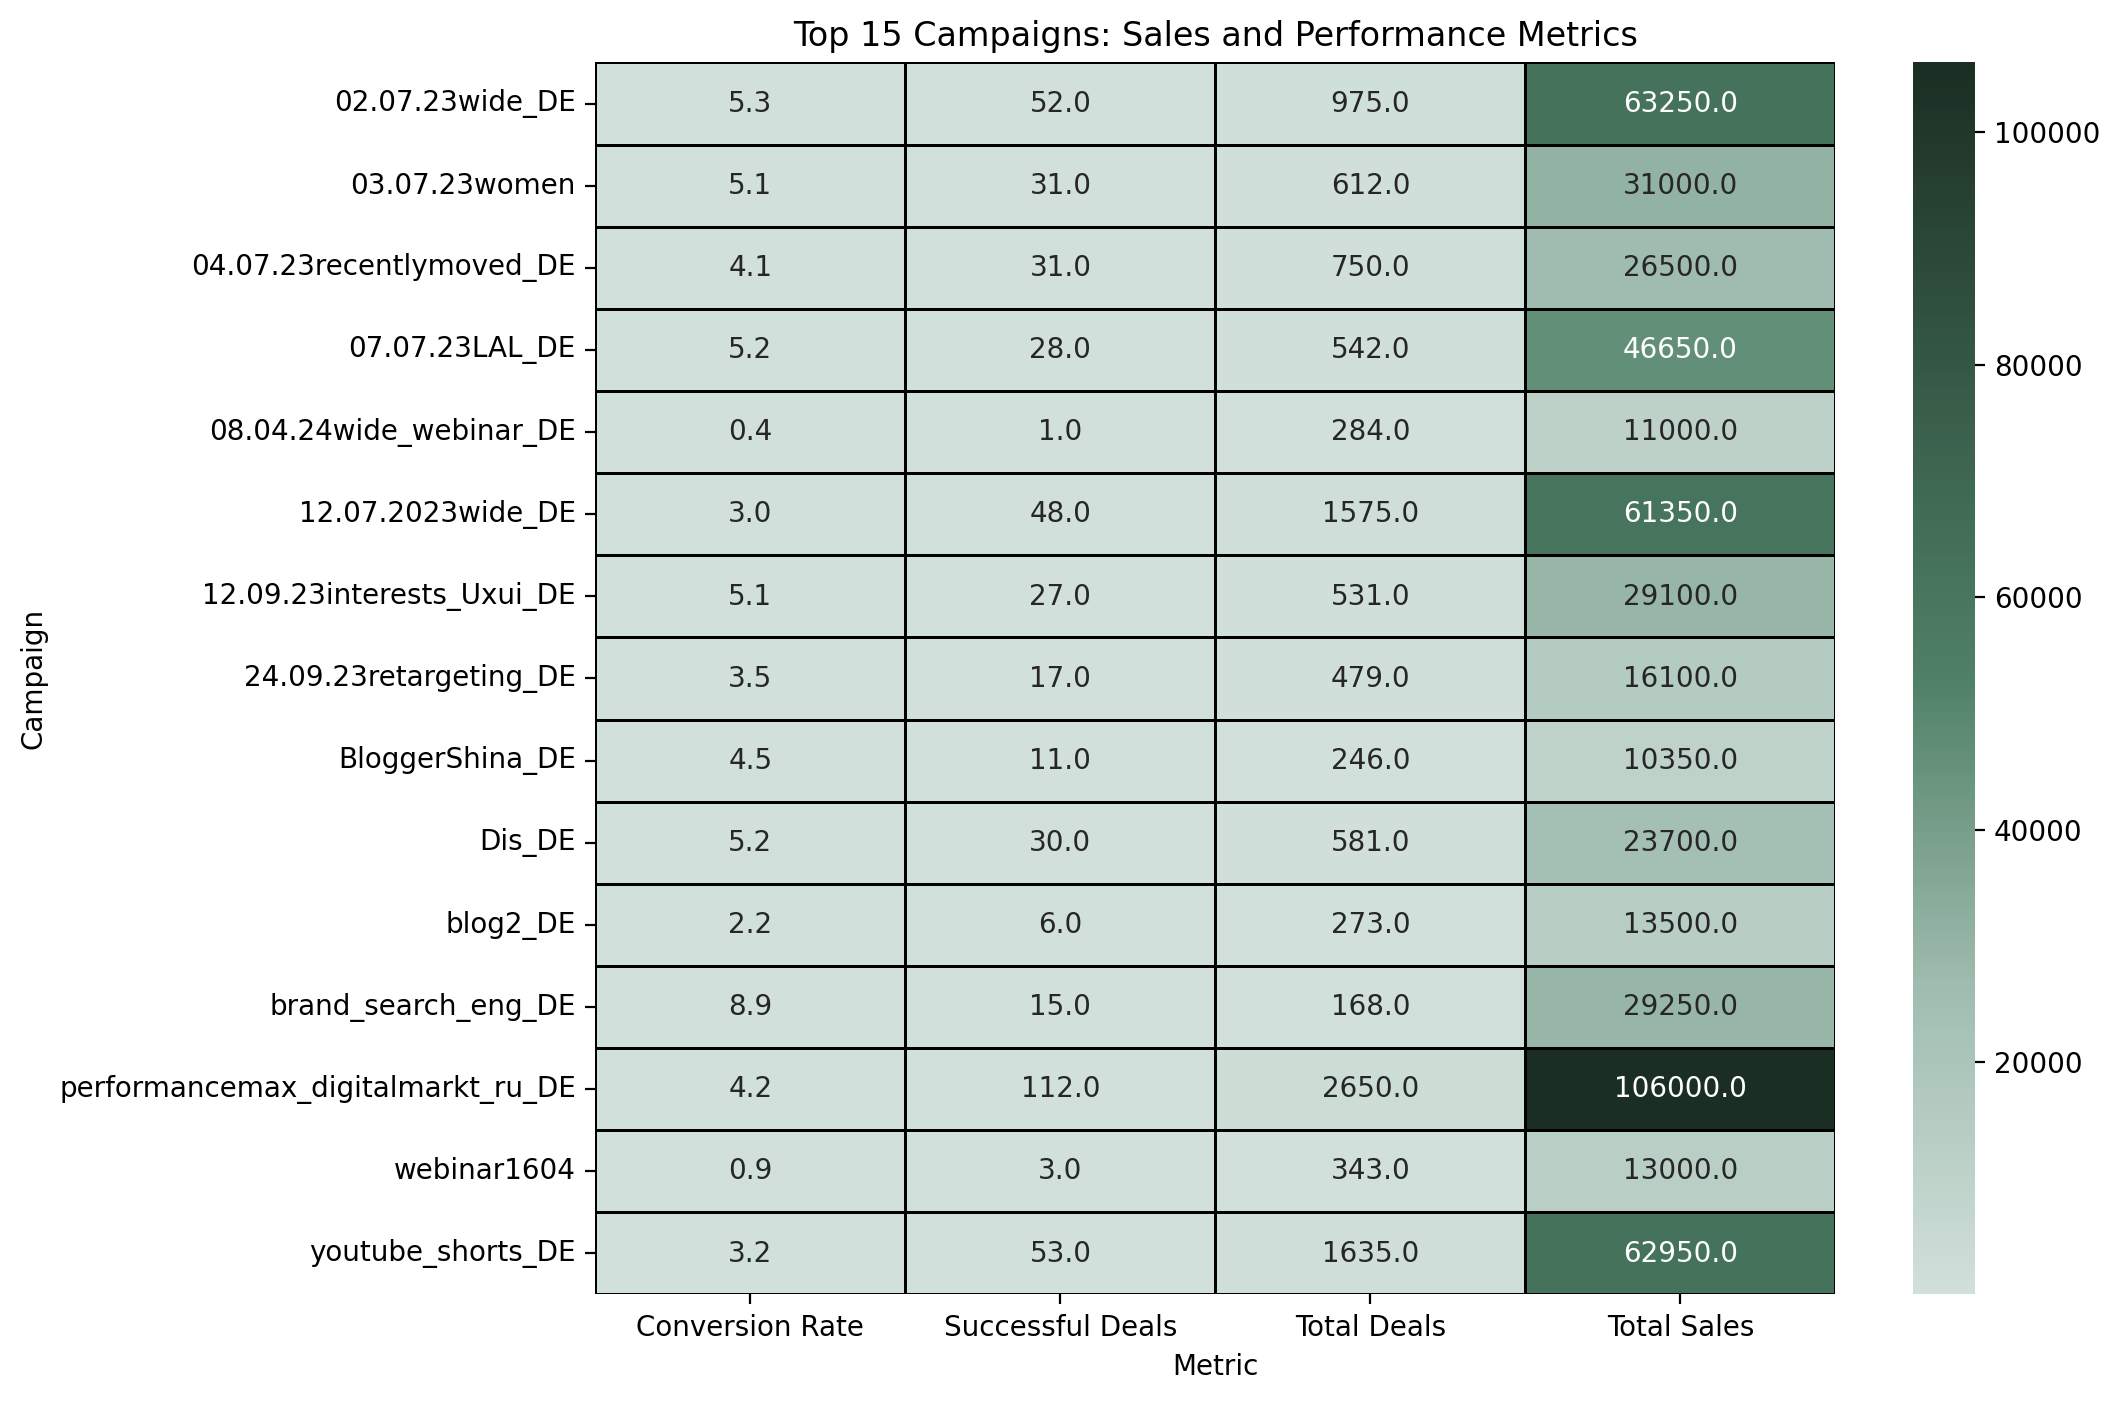

In [31]:
top_campaigns = campaign_analysis.sort_values(
    by='Total_Sales', ascending=False
).head(15)

heatmap_data = top_campaigns[[
        'Campaign',
        'Deals_Total',
        'Deals_Successful',
        'Conversion_Rate',
        'Total_Sales'
    ]]

heatmap_data = heatmap_data.rename(columns={
    'Total_Sales': 'Total Sales',
    'Deals_Total': 'Total Deals',
    'Deals_Successful': 'Successful Deals',
    'Conversion_Rate': 'Conversion Rate'
})

heatmap_melted = heatmap_data.melt(
    id_vars='Campaign',
    value_vars=[
        'Total Deals',
        'Successful Deals',
        'Total Sales',
        'Conversion Rate'
    ],
    var_name='Metric',
    value_name='Value'
)

heatmap_matrix = heatmap_melted.pivot(
    index='Campaign',
    columns='Metric',
    values='Value'
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt='.1f',
    cmap=custom_cmap,
    linewidths=0.5,
    linecolor='black'
)
plt.title('Top 15 Campaigns: Sales and Performance Metrics')
plt.xlabel('Metric')
plt.ylabel('Campaign')
plt.show()

Выводы:
1. Total Sales
- Кампания performancemax_digitalmarkt_ru_DE принесла 106 000 евро выручки, что значительно выше, чем результат ближайших кампаний. Это указывает на высокую масштабируемость и эффективность кампании в Google Ads, несмотря на средний коэффициент конверсии (4.2%).
- Кампании 02.07.23wide_DE, 12.07.2023wide_DE и youtube_shorts_DE генерируют значительный объем продаж (>60 000 евро) за счет большого количества лидов, компенсируя средний уровень конверсии.
- Низкие результаты: Кампании webinar1604, blog2_DE и BloggerShina_DE показывают самый низкий объем продаж (<14 000 евро). Необходимо анализировать их рентабельность, так как затраты на блогеров и организацию вебинаров могут быть высокими.
2. Conversion Rate
- Кампания brand_search_eng_DE демонстрирует очень высокий коэффициент конверсии (8.9%). Это говорит о том, что аудитория, пришедшая из поиска по бренду, уже мотивирована к покупке и имеет высокий интерес.
- Несколько кампаний показывают конверсию выше среднего (~5%): 02.07.23wide_DE, 03.07.23women, 07.07.23LAL_DE, 12.09.23interests_Uxui_DE, Dis_DE. Я считаю, что это хороший показатель для образовательной сферы. Нужно анализировать, за счет чего они держат такой показатель.
- Несмотря на огромное количество лидов (2650), кампания performancemax_digitalmarkt_ru_DE конвертирует в успешные сделки только 4.2%. Это указывает на то, что кампания генерирует много "холодных" лидов, но за счет огромного объема и низкой стоимости лида остается прибыльной.
- Кампании webinar1604 (0.9%) и особенно 08.04.24wide_webinar_DE (0.4%) имеют критически низкую конверсию. Это сигнал к пересмотру стратегии вебинаров: возможно, проблема в привлечении нерелевантной аудитории, качестве самого вебинара или процессе оформления заказа после него.
3. По направлениям:
- wide: большой объем продаж, требует оптимизации для повышения конверсии.
- interests, women: стабильные результаты, правильный выбор тем и аудиторий.
- YouTube Shorts: эффективно привлекает заинтересованную аудиторию.
- Вебинары: низкая конверсия, нужно пересмотреть весь цикл.
- Блогеры: низкая эффективность, стоит пересмотреть выбор инфлюэнсеров и условия сотрудничества.


#`Анализ платежей и продуктов`

## 1. Изучите распределение типов оплаты и их влияние на успешность сделок.

In [32]:
filter_deals = deals[deals['Payment Type'] != 'No_data'].copy()

payment_type_analisis = (
    filter_deals
    .groupby('Payment Type', observed=True)
    .agg(
        Deals_Total=('Stage', 'count'),
        Deals_Successful=('Stage', lambda x: (x == 'Payment Done').sum()),
        Conversion_Rate=(
            'Stage',
            lambda x: (x == 'Payment Done').sum() / len(x) * 100
            if len(x) > 0 else 0
        ),
        Total_Sales=(
            'Initial Amount Paid',
            lambda x: x[
            x.index.isin(filter_deals[
                filter_deals['Stage'] == 'Payment Done'].index)
    ].sum()))
    .reset_index()
)

payment_type_analisis['Conversion_Rate'] = (
    payment_type_analisis['Conversion_Rate'].round(1))

payment_type_analisis

,Payment Type,Deals_Total,Deals_Successful,Conversion_Rate,Total_Sales
0,One Payment,138,112,81.2,232750.0
1,Recurring Payments,349,249,71.3,110900.0
2,Reservation,5,1,20.0,100.0


In [33]:
custom_data = payment_type_analisis[
    ['Deals_Total']].values

bar_custom_data = payment_type_analisis[
    ['Deals_Successful', 'Conversion_Rate']].values

text_positions = [
    'outside' if label == 'Reservation' else 'inside'
    for label in payment_type_analisis['Payment Type']
]
pull_values = [
    0.1 if label == 'Reservation' else 0
    for label in payment_type_analisis['Payment Type']
]

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{'type': 'domain'}, {'type': 'xy'}]],
    subplot_titles=(
        'Deals by Payment Type',
        'Total Sales by Payment Type',
    ),
)

fig.add_trace(
    go.Pie(
        labels=payment_type_analisis['Payment Type'],
        values=payment_type_analisis['Deals_Total'],
        marker_colors=custom_colors,
        textposition=text_positions,
        textinfo='label+percent',
        pull=pull_values,
        customdata=custom_data,
        texttemplate='%{label}<br>Deals: %{customdata[0]}<br>%{percent}',
        showlegend=False,
        hoverinfo='none',
        hovertemplate=None
    ),
    row=1, col=1,
)

fig.add_trace(
    go.Bar(
        x=payment_type_analisis['Payment Type'],
        y=payment_type_analisis['Total_Sales'],
        marker_color=custom_colors,
        texttemplate='%{y}<br>Successful: %{customdata[0]}',
        textposition='inside',
        customdata=bar_custom_data,
        hovertemplate=(
            '<b>%{x}</b><br>'
            'Conversion Rate: %{customdata[1]:.1f}%<extra></extra>'
        ),
        showlegend=False,
    ),
    row=1, col=2,
)

fig.update_yaxes(
    title_text='Total Sales (€)',
    row=1,
    col=2
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
   title=dict(
        text='Payment Type Analysis',
        font=dict(size=18),
        x=0.5,
        xanchor='center'
    ),
    showlegend=False,
)

fig.show()

Выводы:
- Основной доход компании формируется за счёт разовых платежей. Повторяющиеся платежи приносят вдвое меньше дохода, а резервирование почти не влияет на финансовый результат.
- Стоит отметить, что повторяющиеся платежи выбирает большинство клиентов, что положительно сказывается на общей конверсии. Разовые платежи демонстрируют более высокую конверсию у отдельных клиентов, вероятно, потому что такие клиенты уже точно определились с выбором курса.
- С учетом полученных данных, конверсия разовых платежей составляет 81%, а повторяющихся — 71%, что является очень высоким показателем.
- Разнообразие вариантов оплаты важно для бизнеса, так как удобный и подходящий способ оплаты может быть решающим фактором при выборе обучения.
- Необходимо пересмотреть стратегию и условия резервирования, поскольку текущая схема практически не влияет на доходы и может быть нецелесообразной.

## 2. Проанализируйте популярность и успешность различных продуктов и типов обучения.

In [34]:
filter_product = deals[deals['Product'] != 'No_data'].copy()

product_analisis = (
    filter_product
    .groupby('Product', observed=True)
    .agg(
        Deals_Total=('Stage', 'count'),
        Deals_Successful=('Stage', lambda x: (x == 'Payment Done').sum()),
        Conversion_Rate=(
            'Stage', lambda x: (x == 'Payment Done').sum() / len(x) * 100
            if len(x) > 0 else 0
        ),
        Total_Sales=(
            'Initial Amount Paid',
            lambda x: x[
                x.index.isin(filter_product[
                    filter_product['Stage'] == 'Payment Done'].index)
    ].sum()))
    .reset_index()
)

product_analisis['Conversion_Rate'] = (
    product_analisis['Conversion_Rate'].round(1))

product_analisis

,Product,Deals_Total,Deals_Successful,Conversion_Rate,Total_Sales
0,Digital Marketing,1981,472,23.8,529900.0
1,UX/UI Design,1013,229,22.6,275100.0
2,Web Developer,573,136,23.7,143150.0


In [35]:
fig = go.Figure()

total_text = [
    f'{deals} | Sales: {int(sales):,} €'
    for deals, sales in zip(
        product_analisis['Deals_Total'],
        product_analisis['Total_Sales'])
]

fig.add_trace(
    go.Bar(
        x=product_analisis['Deals_Total'],
        y=product_analisis['Product'],
        name='Total Deals',
        orientation='h',
        marker=dict(color='#4F8166'),
        text=total_text,
        textposition='inside',
        textfont=dict(color='white', size=12),
        customdata=product_analisis['Conversion_Rate'],
        hoverinfo='skip'
    )
)

successful_text = [
    f'{succ} | CR: {cr:.1f}%'
    for succ, cr in zip(
        product_analisis['Deals_Successful'],
        product_analisis['Conversion_Rate'])
]

fig.add_trace(
    go.Bar(
        x=product_analisis['Deals_Successful'],
        y=product_analisis['Product'],
        name='Successful Deals',
        orientation='h',
        marker=dict(color='#244993'),
        text=successful_text,
        textposition='inside',
        textfont=dict(color='white', size=12),
        hoverinfo='skip'
    )
)

fig.update_layout(
    title=dict(
        text='Product Popularity and Success',
        font=dict(size=18)
    ),
    barmode='group',
    xaxis=dict(visible=False),
    yaxis_title='Product',
    template='plotly_white',
    height=400,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.15,
        xanchor='center',
        x=0.5
    )
)

fig.show()

Выводы:
- Digital Marketing лидирует по всем ключевым показателям: общее количество сделок, успешные сделки и продажи. Формирует основной доход продаж.
- Конверсия успешных сделок примерно одинаковая для всех трёх продуктов (~23%), что говорит о стабильности качества продаж независимо от продукта.
- Есть потенциал для увеличения популярности Web Developer и UX/UI Design, так как их конверсия не уступает лидеру, но количество клиентов меньше.

In [36]:
filter_education_type = deals[
    (deals['Education Type'] != 'No_data') &
    (deals['Product'] != 'No_data')
].copy()

education_type_analisis = (
    filter_education_type
    .groupby(['Product', 'Education Type'], observed=True)
    .agg(
        Deals_Total=('Stage', 'count'),
        Deals_Successful=('Stage', lambda x: (x == 'Payment Done').sum()),
        Conversion_Rate=(
            'Stage',
            lambda x: (x == 'Payment Done').sum() / len(x) * 100
            if len(x) > 0 else 0
        ),
        Total_Sales=(
            'Initial Amount Paid',
            lambda x: x[x.index.isin(
                filter_education_type[
                    filter_education_type['Stage'] == 'Payment Done'].index
            )].sum()
        )
    )
    .reset_index()
)

education_type_analisis['Conversion_Rate'] = (
    education_type_analisis['Conversion_Rate'].round(1))

education_type_analisis

,Product,Education Type,Deals_Total,Deals_Successful,Conversion_Rate,Total_Sales
0,Digital Marketing,Evening,250,113,45.2,95200.0
1,Digital Marketing,Morning,1524,352,23.1,427700.0
2,UX/UI Design,Evening,153,58,37.9,61300.0
3,UX/UI Design,Morning,799,171,21.4,213800.0
4,Web Developer,Evening,1,0,0.0,0.0
5,Web Developer,Morning,543,136,25.0,143150.0


In [38]:
pivot_data = education_type_analisis.pivot(
    index='Product', columns='Education Type', values='Deals_Successful')

pivot_sales = education_type_analisis.pivot(
    index='Product', columns='Education Type', values='Total_Sales')

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=pivot_data.index,
        y=pivot_data['Morning'],
        name='Morning',
        marker_color='#97B364',
        text=[
            f"{deals:,} deals<br> {int(sales):,} €"
            for deals, sales in zip(
                pivot_data['Morning'], pivot_sales['Morning'])
        ],
        textposition='inside',
        insidetextanchor='middle',
        textfont=dict(color='white', size=12),
        hovertemplate=[
            f'Product: {p}<br>Deals Successful: {y}<br>Sales: {s:,.0f} €'
            for p, y, s in zip(
                pivot_data.index, pivot_data['Morning'], pivot_sales['Morning'])
        ]
    )
)

fig.add_trace(
    go.Bar(
        x=pivot_data.index,
        y=pivot_data['Evening'],
        name='Evening',
        marker_color='#214B63',
        text=[
            f"{deals:,} deals <br> {int(sales):,} €"
            for deals, sales in zip(
                pivot_data['Evening'], pivot_sales['Evening'])
        ],
        textposition='inside',
        insidetextanchor='middle',
        textfont=dict(color='white', size=12),
        hovertemplate=[
            f'Product: {p}<br>Deals Successful: {y}<br>Sales: {s:,.0f} €'
            for p, y, s in zip(
                pivot_data.index, pivot_data['Evening'], pivot_sales['Evening'])
        ]
    )
)

fig.update_layout(
    title='Successful Deals and Sales by Product and Session',
    xaxis=dict(
        title='Course',
        showgrid=False,
        showline=True,
        linecolor='black'
    ),
    yaxis=dict(
        title='Successful Deals',
        showticklabels=False,
        showgrid=False,
        zeroline=False
    ),
    barmode='group',
    template='plotly_white',
    height=500,
    legend=dict(
        title='Session',
        orientation="v",
        xanchor="right",
        x=1,
        yanchor='top',
        y=1,
        bordercolor='black'
    )
)

fig.show()

Выводы:
- Digital Marketing - продажа утренних курсов почти в 4,5 раза выше, чем вечерних.
- UX/UI Design Course - продажа вдвое ниже по числу сделок и почти в 2 раза ниже по выручке.
- Web Developer - данные курсы успешно продаются только утром. Вечером отсутствует спрос или не реализуется вовсе.
- В целом, утренние курсы приносят существенно больше успешных сделок и выручки по всем продуктам, чем вечерние.
- Необходим пересмотр вечерней стратегии: спрос есть, но низкий. Возможно, стоит изменить маркетинг или предложение под вечернюю аудиторию.
- Высокий разрыв между продуктами указывает на необходимость усиливать продвижение Web Developer и UX/UI Design, особенно в вечерние часы.



#`Географический анализ`

### Создание JSON

In [ ]:
api_key = 'insert key' # ввести ключ


def get_city_and_state_info(city_name):
    try:
        url = (
            f'https://maps.googleapis.com/maps/api/geocode/json?'
            f'address={city_name}&key={api_key}&language=de'
        )
        response = requests.get(url)

        if response.status_code == 200:
            data = response.json()

            if not data['results']:
                print(f'No data found for {city_name}')
                return None, data

            result = data['results'][0]
            location = result['geometry']['location']
            latitude = location['lat']
            longitude = location['lng']
            components = result['address_components']

            country = next(
                (c['long_name'] for c in components if 'country' in c['types']),
                None
            )
            federal_state = next(
                (c['long_name'] for c in components
                if 'administrative_area_level_1' in c['types']),
                None
            )
            region = next(
                (c['long_name'] for c in components
                if 'administrative_area_level_2' in c['types']),
                None
            )

            if country == 'Germany':
                location_level = federal_state
            else:
                location_level = federal_state or region

            return {
                'city': city_name,
                'country': country,
                'federal_state_or_region': location_level,
                'latitude': latitude,
                'longitude': longitude
            }, data

        else:
            print(f'Ошибка: статус код {response.status_code} для {city_name}')
            return None, None

    except Exception as e:
        print(f'Ошибка при получении данных для {city_name}: {e}')
        return None, None

In [ ]:
cities = deals[deals['City'] != 'No_data']['City'].unique()

responses = []
no_data_cities = []
city_data = {}

for city in tqdm(cities, desc='Processing cities', unit='city'):
    city_info, json_response = get_city_and_state_info(city)
    if city_info:
        city_data[city] = city_info
    else:
        no_data_cities.append(city)

    if json_response:
        responses.append(json_response)
    time.sleep(0.2)

print('\nГорода без данных:', no_data_cities)
print('\nJSON-ответы:', responses)

Processing cities:  25%|██▍       | 213/868 [00:53<02:46,  3.94city/s]

No data found for Piatek


Processing cities:  47%|████▋     | 404/868 [01:41<01:56,  3.99city/s]

No data found for Helmstidde


Processing cities:  81%|████████  | 704/868 [02:56<00:41,  3.99city/s]

No data found for Wetter


Processing cities: 100%|██████████| 868/868 [03:37<00:00,  3.98city/s]


Города без данных: ['Piatek', 'Helmstidde', 'Wetter']

JSON-ответы: [{'results': [{'address_components': [{'long_name': 'Berlin', 'short_name': 'Berlin', 'types': ['locality', 'political']}, {'long_name': 'Kreisfreie Stadt Berlin', 'short_name': 'Kreisfreie Stadt Berlin', 'types': ['administrative_area_level_3', 'political']}, {'long_name': 'Berlin', 'short_name': 'BE', 'types': ['administrative_area_level_1', 'political']}, {'long_name': 'Deutschland', 'short_name': 'DE', 'types': ['country', 'political']}], 'formatted_address': 'Berlin, Deutschland', 'geometry': {'bounds': {'northeast': {'lat': 52.6754542, 'lng': 13.7611175}, 'southwest': {'lat': 52.338234, 'lng': 13.088346}}, 'location': {'lat': 52.52000659999999, 'lng': 13.404954}, 'location_type': 'APPROXIMATE', 'viewport': {'northeast': {'lat': 52.6754542, 'lng': 13.7611175}, 'southwest': {'lat': 52.338234, 'lng': 13.088346}}}, 'place_id': 'ChIJAVkDPzdOqEcRcDteW0YgIQQ', 'types': ['locality', 'political']}], 'status': 'OK'}, {'re

In [ ]:
no_results_cities = list(map(lambda x: x + ' город', no_data_cities))
display(no_results_cities)

['Piatek город', 'Helmstidde город', 'Wetter город']

In [ ]:
no_data_cities = []

for city_with_suffix in tqdm(
                no_results_cities, desc='Processing cities', unit='city'):
    city_info, json_response = get_city_and_state_info(city_with_suffix)

    if city_info:
        clean_city_name = city_with_suffix.replace(' город', '')
        city_info['city'] = clean_city_name
        city_data[clean_city_name] = city_info
    else:
        no_data_cities.append(city_with_suffix)

    if json_response:
        responses.append(json_response)

    time.sleep(0.2)

print('\nГорода без данных:', no_data_cities)

Processing cities:  33%|███▎      | 1/3 [00:00<00:00,  3.75city/s]

No data found for Helmstidde город


Processing cities: 100%|██████████| 3/3 [00:00<00:00,  3.92city/s]


Города без данных: ['Helmstidde город']


In [ ]:
city_info, response = get_city_and_state_info('Хельмштедт')

if city_info:
    city_info['city'] = 'Helmstidde'
    city_data['Helmstidde'] = city_info

if response:
    responses.append(response)

In [ ]:
cities = deals[deals['City'] != 'No_data']['City'].unique()

processed_cities = set(city_data.keys())
all_cities = set(cities)

missing_cities = all_cities - processed_cities

if missing_cities:
    print('Города без данных после обработки:', missing_cities)
else:
    print('Данные есть по всем городам')

Данные есть по всем городам


In [ ]:
file_path_json = '/content/drive/My Drive/_Project/Files/city_data_google.json'

with open(file_path_json, 'w') as json_file:
    json.dump(city_data, json_file, indent=4)

print(f'Файл сохранен: {file_path_json}')

Файл сохранен: /content/drive/My Drive/_Project/Files/city_data_google.json


### Работа с картой

In [39]:
file_path_json = '/content/drive/My Drive/_Project/Files/city_data_google.json'

with open(file_path_json, "r") as json_file:
    city_data = json.load(json_file)

In [ ]:
# city_data

In [40]:
def get_city_info(city):
    info = city_data.get(city, {})
    return pd.Series({
        'longitude': info.get('longitude', None),
        'latitude': info.get('latitude', None),
        'country': info.get('country', None),
        'federal_state_or_region': info.get('federal_state_or_region', None),
        'city_ru': info.get('city', None)
    })


deals[['longitude', 'latitude', 'country',
       'federal_state_or_region', 'city']] = deals['City'].apply(get_city_info)

In [41]:
deals.loc[deals.City != "No_data"].head()

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,Content,Term,...,Level of Deutsch,SLA Seconds,Deal Created Date,Deals Closing Month,Duration,longitude,latitude,country,federal_state_or_region,city
35,5805028000056714532,Ulysses Adams,NaT,No_data,Registered on Webinar,No_data,/webinar,webinar1906,NaN,invitation,...,Unknown,NaN,2024-06,NaT,NaN,13.404954,52.520007,Deutschland,Berlin,Berlin
42,5805028000056731279,Ulysses Adams,NaT,No_data,Registered on Webinar,No_data,/webinar,NaN,NaN,NaN,...,Unknown,NaN,2024-06,NaT,NaN,7.609363,50.307827,Deutschland,Rheinland-Pfalz,Lahnstein
56,5805028000056683030,Charlie Davis,NaT,C - Low,Waiting For Payment,No_data,/eng/test,performancemax_eng_DE,_{region_name}_,NaN,...,Unknown,1239.0,2024-06,NaT,NaN,10.063357,49.133735,Deutschland,Baden-Württemberg,Crailsheim
57,5805028000056568397,Paula Underwood,NaT,No_data,Registered on Webinar,No_data,/webinar,NaN,NaN,NaN,...,B1,NaN,2024-06,NaT,NaN,13.862376,53.316844,Deutschland,Brandenburg,Prenzlau
60,5805028000056558351,Ulysses Adams,NaT,C - Low,Waiting For Payment,No_data,/eng,NaN,NaN,NaN,...,B1,589.0,2024-06,NaT,NaN,7.465298,51.513587,Deutschland,Nordrhein-Westfalen,Dortmund


In [42]:
geo_deals = deals[['Id', 'City']]
geo_deals_clean = geo_deals.dropna(subset=['City'])

deals_by_city = (
    geo_deals_clean
    .groupby('City')
    .size()
    .reset_index(name='Number of Deals')
)

deals_by_city_sorted = deals_by_city.sort_values(
    by='Number of Deals', ascending=False
)

deals_by_city_sorted.head(10)

,City,Number of Deals
561,No_data,18595
88,Berlin,282
521,München,90
288,Hamburg,82
571,Nürnberg,54
429,Leipzig,54
177,Düsseldorf,53
169,Dresden,36
222,Frankfurt,35
168,Dortmund,34


In [43]:
geo_data_deals = deals[
    ['City', 'longitude', 'latitude',
     'country', 'federal_state_or_region', 'city']
].drop_duplicates(
    subset=['City']
).dropna()

geo_data_deals.head(10)

,City,longitude,latitude,country,federal_state_or_region,city
35,Berlin,13.404954,52.520007,Deutschland,Berlin,Berlin
42,Lahnstein,7.609363,50.307827,Deutschland,Rheinland-Pfalz,Lahnstein
56,Crailsheim,10.063357,49.133735,Deutschland,Baden-Württemberg,Crailsheim
57,Prenzlau,13.862376,53.316844,Deutschland,Brandenburg,Prenzlau
60,Dortmund,7.465298,51.513587,Deutschland,Nordrhein-Westfalen,Dortmund
65,Stuttgart,9.182932,48.775846,Deutschland,Baden-Württemberg,Stuttgart
71,München,11.581981,48.135125,Deutschland,Bayern,München
94,Wien,16.371309,48.208070,Österreich,Wien,Wien
98,Offenbach am Main,8.776084,50.095636,Deutschland,Hessen,Offenbach am Main
113,Eberbach,8.989844,49.469481,Deutschland,Baden-Württemberg,Eberbach


In [44]:
deals_by_city_sorted = deals_by_city_sorted.merge(
    geo_data_deals, on='City', how='inner'
)
deals_by_city_sorted.head()

,City,Number of Deals,longitude,latitude,country,federal_state_or_region,city
0,Berlin,282,13.404954,52.520007,Deutschland,Berlin,Berlin
1,München,90,11.581981,48.135125,Deutschland,Bayern,München
2,Hamburg,82,9.987170,53.548828,Deutschland,Hamburg,Hamburg
3,Nürnberg,54,11.074564,49.454288,Deutschland,Bayern,Nürnberg
4,Leipzig,54,12.373075,51.339695,Deutschland,Sachsen,Leipzig


In [45]:
deals_by_state = (
    deals_by_city_sorted.groupby('federal_state_or_region')
    .agg({'Number of Deals': 'sum'})
    .reset_index()
)

deals_by_state_sorted = deals_by_state.sort_values(
    by='Number of Deals', ascending=False).head(10)

deals_by_state_sorted

,federal_state_or_region,Number of Deals
32,Nordrhein-Westfalen,565
7,Bayern,477
5,Baden-Württemberg,366
8,Berlin,282
31,Niedersachsen,204
20,Hessen,190
47,Sachsen,149
45,Rheinland-Pfalz,103
18,Hamburg,82
48,Sachsen-Anhalt,58


In [46]:
top_10_cities = deals_by_city_sorted.head(10)
top_10_states = deals_by_state_sorted.head(10)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        name='Number of Deals',
        x=top_10_cities['City'],
        y=top_10_cities['Number of Deals'],
        visible=True,
        marker=dict(color='#214B63'),
        hovertemplate=(
            'City: %{x}<br>'
            'Number of Deals: %{y}<extra></extra>'),
    ))

fig.add_trace(
    go.Bar(
        name='Number of Deals',
        x=top_10_states['federal_state_or_region'],
        y=top_10_states['Number of Deals'],
        visible=False,
        marker=dict(color='#244993'),
        hovertemplate=(
            'Federal State: %{x}<br>'
            'Number of Deals: %{y}<extra></extra>'),
    ))

fig.update_layout(
    title='Top 10 Cities or Federal States by Number of Deals',
    xaxis_title='Location',
    yaxis_title='Number of Deals',
    xaxis_tickangle=-45,
    updatemenus=[
        dict(
            type='buttons',
            direction='right',
            x=0.5,
            y=1.15,
            showactive=True,
            buttons=[
                dict(
                    label='Cities',
                    method='update',
                    args=[
                        {'visible': [True, False]},
                        {'title': 'Top 10 Cities by Number of Deals'},
                    ],
                ),
                dict(
                    label='Federal States',
                    method='update',
                    args=[
                        {'visible': [False, True]},
                        {'title': 'Top 10 Federal States by Number of Deals'},
                    ],
                ),
            ],
        )
    ],
)

fig.show()

Выводы:

На графике показаны топ-10 городов по количеству созданных сделок, а также топ-10 по федеральным землям.

Основные причины большого количества созданных сделок в этих городах могут быть следующими:
- это крупные экономические центры Германии с развитой инфраструктурой и бизнес-средой, что стимулирует активность сделок.
- в Берлине как столице сосредоточены штаб-квартиры многих компаний, стартапов и международных организаций, что создает большое количество возможностей.
- Мюнхен и Гамбург — важные финансовые и промышленные центры, привлекающие инвестиции и деловую активность.
- размер и численность населения также влияют на общее число сделок — чем больше город, тем больше потенциальных участников рынка.

Основные причины большого числа сделок в этих федеральных землях:
- Северный Рейн-Вестфалия — самая густонаселенная и экономически развитая земля Германии с множеством крупных городов.
- Бавария известна сильной промышленностью, технологиями и экономическим ростом, включая крупный центр — Мюнхен.
- Другие земли, такие как Берлин, Нижняя Саксония, Гессен и Саксония, также имеют развитые экономические центры и инфраструктуру, что отражается на активности сделок.

In [47]:
deals_geo = deals_by_city_sorted[
    deals_by_city_sorted['City'] != 'No_data'
].dropna(subset=['City'])

geometry = [Point(xy) for xy in zip(
    deals_geo['longitude'], deals_geo['latitude'])]
gdf = gpd.GeoDataFrame(deals_geo, geometry=geometry, crs='EPSG:4326')

deals_by_state = (
    deals_geo.groupby('federal_state_or_region')
    .agg({'Number of Deals': 'sum'})
    .reset_index()
)

local_path = '/content/drive/My Drive/_Project/Files/2_hoch.geo.json'
gdf_states = gpd.read_file(local_path)

gdf_states = gdf_states.merge(
    deals_by_state,
    left_on='name',
    right_on='federal_state_or_region',
    how='left'
)
gdf_states['Number of Deals'] = gdf_states['Number of Deals'].fillna(0)

center = gdf.geometry.union_all().centroid
m = folium.Map(location=[center.y, center.x], zoom_start=6)

folium.GeoJson(
    gdf_states,
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'blue',
        'weight': 2
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'Number of Deals'],
        aliases=['Federal State:', 'Total Deals:'],
        localize=True
    )
).add_to(m)

marker_cluster = MarkerCluster().add_to(m)

for _, row in gdf.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3 + row['Number of Deals'] * 0.5,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.7,
        popup=f'City: {row["City"]}<br>Deals: {row["Number of Deals"]}'
    ).add_to(marker_cluster)

m.save('deals_map_cluster_states.html')
m

Географичекая карта с распределение общего числа зарегистрированных сделок подтверждает выводы, описанные под предыдущим графиком.  

### 2. Изучаю влияние уровня знания немецкого языка на успешность сделок в разных городах

In [48]:
filter_deals = deals[deals['City'] != 'No_data'].copy()

successful_deals = filter_deals[
    (filter_deals['Stage'] == 'Payment Done') &
    (filter_deals['Level of Deutsch'] != 'Unknown')
].copy()

total_deals = (filter_deals.groupby('City').size()
                    .reset_index(name='Deals_Total'))

successful_counts = (successful_deals.groupby('City').size()
                    .reset_index(name='Deals_Successful'))

language_pivot = pd.crosstab(
    successful_deals['City'],
    successful_deals['Level of Deutsch']
).reset_index()

language_pivot

Level of Deutsch,City,A0,A1,A2,B1,B2,C1,C2
0,Aachen,0,0,0,2,0,0,0
1,Ahaus,0,0,0,0,1,0,0
2,Aichwald,0,0,0,1,0,0,0
3,Alfeld,0,0,0,1,0,0,0
4,Altshausen,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...
190,Wülfrath,0,0,0,1,0,0,0
191,Zeitz,0,0,0,1,0,0,0
192,Zorneding,0,0,0,1,0,0,0
193,Zwickau,0,0,1,0,0,0,0


In [49]:
city_summary = total_deals.merge(successful_counts, on='City', how='left')
city_summary = city_summary.merge(language_pivot, on='City', how='left')
city_summary = city_summary.fillna(0)

numeric_cols = city_summary.columns.drop('City')
city_summary[numeric_cols] = city_summary[numeric_cols].astype(int)

city_summary['Conversion_Rate'] = round(
    city_summary['Deals_Successful'] / city_summary['Deals_Total'] * 100, 1
)

city_summary = city_summary.sort_values(
    by='Deals_Total', ascending=False
).reset_index(drop=True)

city_summary

,City,Deals_Total,Deals_Successful,A0,A1,A2,B1,B2,C1,C2,Conversion_Rate
0,Berlin,282,36,0,1,2,25,6,2,0,12.8
1,München,90,10,1,0,2,3,4,0,0,11.1
2,Hamburg,82,11,1,0,1,4,5,0,0,13.4
3,Nürnberg,54,6,0,0,0,4,2,0,0,11.1
4,Leipzig,54,12,0,0,1,9,2,0,0,22.2
...,...,...,...,...,...,...,...,...,...,...,...
863,Albstadt,1,0,0,0,0,0,0,0,0,0.0
864,Ajman,1,0,0,0,0,0,0,0,0,0.0
865,Aichwald,1,1,0,0,0,1,0,0,0,100.0
866,Überlingen,1,0,0,0,0,0,0,0,0,0.0


In [50]:
top_10_cities = city_summary.head(10)['City']
data_10_top = city_summary[city_summary['City'].isin(top_10_cities)].copy()

data_10_top

,City,Deals_Total,Deals_Successful,A0,A1,A2,B1,B2,C1,C2,Conversion_Rate
0,Berlin,282,36,0,1,2,25,6,2,0,12.8
1,München,90,10,1,0,2,3,4,0,0,11.1
2,Hamburg,82,11,1,0,1,4,5,0,0,13.4
3,Nürnberg,54,6,0,0,0,4,2,0,0,11.1
4,Leipzig,54,12,0,0,1,9,2,0,0,22.2
5,Düsseldorf,53,3,0,0,0,2,1,0,0,5.7
6,Dresden,36,7,0,0,0,5,2,0,0,19.4
7,Frankfurt,35,2,0,0,2,0,0,0,0,5.7
8,Dortmund,34,2,0,0,1,1,0,0,0,5.9
9,Köln,32,5,0,0,2,1,2,0,0,15.6


In [51]:
data_long = data_10_top.melt(
    id_vars=['City', 'Deals_Total', 'Deals_Successful', 'Conversion_Rate'],
    value_vars=['A0','A1','A2','B1','B2','C1','C2'],
    var_name='Level',
    value_name='Deals_Count'
)

group_map = {
    'A0': 'A0-A2', 'A1': 'A0-A2', 'A2': 'A0-A2',
    'B1': 'B1-B2', 'B2': 'B1-B2',
    'C1': 'C1-C2', 'C2': 'C1-C2'
}
data_long['Group'] = data_long['Level'].map(group_map)

grouped = (
    data_long.groupby(['City', 'Group'])
    .agg({
        'Deals_Count': 'sum',
        'Deals_Total': 'first',
        'Deals_Successful': 'first',
        'Conversion_Rate': 'first'
    })
    .reset_index()
)

max_group_per_city = grouped.loc[
    grouped.groupby('City')['Deals_Total'].idxmax()
].reset_index(drop=True)

In [52]:
group_colors = {
    'A0-A2': custom_green_gradient[0],
    'B1-B2': custom_green_gradient[2],
    'C1-C2': custom_green_gradient[4]
}

fig = go.Figure()

for group in ['A0-A2', 'B1-B2', 'C1-C2']:
    group_data = grouped[grouped['Group'] == group].copy()

    fig.add_trace(
        go.Bar(
            x=group_data['City'],
            y=group_data['Deals_Count'],
            name=f'Group {group}',
            marker=dict(color=group_colors[group]),
            hovertemplate=(
                'Group: %{customdata[2]}<br>'
                'Deals_Total: %{customdata[0]}<br>'
                'Deals_Successful: %{customdata[1]}<br>'
                'Conversion_Rate: %{customdata[3]}%<extra></extra>'
            ),
            customdata=group_data[
                ['Deals_Total', 'Deals_Successful', 'Group', 'Conversion_Rate']
            ].values
        )
    )

fig.update_layout(
    barmode='group',
    title='Successful Deals by German Level Groups in Top-10 Cities',
    title_font=dict(size=18),
    xaxis=dict(
        title='City',
        tickangle=-45,
        showgrid=False,
        showline=True,
        linecolor='black',
        ticks='outside'
    ),
    yaxis=dict(
        title='Number of Deals',
        showgrid=False,
        showline=True,
        linecolor='black',
        ticks='outside'
    ),
    plot_bgcolor='white',
    hovermode='closest',
    margin=dict(t=80, b=150, l=100),
    legend=dict(
        title='German Level Group',
        orientation="v",
        xanchor="right",
        x=1,
        yanchor="top",
        y=1,
        bgcolor="rgba(255,255,255,0.6)",
        bordercolor="black",
        borderwidth=0
    )
)

fig.show()

Выводы:
- После разделения на условные группы слабого, уверенного и продвинутого знания немецкого языка, мы видим доминирующее значение уровней B1-B2 для принятия решения пройти обучения на курсах компании. Это может говорить о том, что люди принимают решение идти учиться, понимая, что языковой барьер при последующем поиске работы уже частично решен. Также нельзя отрицать, что возможно маркетинговые материалы больше ориентированы на эту группу.
- Предполагаю, что потенциальных клиентов с уровнем A0-A2 пугает перспектива того, что закончив курсы и не зная языка, они все равно не смогут найти работу.
Компании стоит задуматься о совершенствовании аргументации в пользу того, чтобы доказать потенциальному клиенту необходимость начать обучение уже "сегодня".
- Продвинутый уровень (C1-C2) мало представлен. Возможно, такие люди уже достигли своих целей или ищут более специализированные/продвинутые курсы, не предлагаемые фирмой. Необходимо провести анализ возможных предложений для такой группы людей.